<a href="https://colab.research.google.com/github/TurkuNLP/intro-to-nlp/blob/master/intro_ex6_solution_hftok.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

Before we start running our own Python code, we need to install the required Python packages using [pip](https://en.wikipedia.org/wiki/Pip):

* [`transformers`](https://huggingface.co/docs/transformers/index) is a popular deep learning package primarily on top of torch. Sadly, we need to reinstall it to its latest version because of a bug in the default version right now available on Colab
* [`datasets`](https://huggingface.co/docs/datasets/) provides support for loading, creating, and manipulating datasets
* evaluate is a library of performance metrics (like accuracy etc.)

**You might need to do a Runtime/Restart session for everything to work after the installation.**

In [21]:
!pip3 install -q evaluate
!pip3 install -q --upgrade transformers[torch]

(Above, the `!` at the start of the line tells the notebook to run the line as an operating system command rather than Python code, and the `-q` argument to `pip` runs the command in "quiet" mode, with less output.)

In [22]:
import datasets
import evaluate
import transformers
import torch
from pprint import pprint #pprint => pretty-print, I use it occassionally throughout the notebook

#hope everything worked! :)

---

# Get and prepare data

*   Let us work with the IMDB dataset of movie review sentiment
*   25,000 positive reviews
*   25,000 negative reviews
*   50,000 unlabeled reviews (which we discard for the time being)


In [23]:
dset=datasets.load_dataset("imdb")
pprint(dset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [24]:
dset=dset.shuffle() #This is never a bad idea, datasets may have ordering to them, which is not what we want
del dset["unsupervised"] #Delete the unlabeled part of the dataset, we don't need it for anything

In [25]:
pprint(dset['train'][0]['text'])
print(dset['train'][0]['label'])

('There is no relation at all between Fortier and Profiler but the fact that '
 'both are police series about violent crimes. Profiler looks crispy, Fortier '
 "looks classic. Profiler plots are quite simple. Fortier's plot are far more "
 'complicated... Fortier looks more like Prime Suspect, if we have to spot '
 'similarities... The main character is weak and weirdo, but have '
 '"clairvoyance". People like to compare, to judge, to evaluate. How about '
 'just enjoying? Funny thing too, people writing Fortier looks American but, '
 "on the other hand, arguing they prefer American series (!!!). Maybe it's the "
 'language, or the spirit, but I think this series is more English than '
 'American. By the way, the actors are really good and funny. The acting is '
 'not superficial at all...')
1


## Tokenize

*   We need text tokenizer compatible with the rest of the training code
*   For this, we have two options:
    1.    Use the tokenizer from some pre-trained model available on HuggingFace, like BERT or XLM-R
    2.    Build our own tokenizer on the training data
*   We pursue the latter option to minimize the number of tokens/features unseen during training, because we will be inspecting these more closely, and our training data is quite small.


In [26]:
## The simple way -> use a readymade tokenizer; for example xlm-roberta-base is a good highly multilingual model
#tokenizer = transformers.AutoTokenizer.from_pretrained("FacebookAI/xlm-roberta-base")
#tokenizer = transformers.AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")
### These are good general purpose tokenizers BUT do not really fit our needs -> we only have 25K of movie
### reviews; the tokenizer vocabulary would be too large for this

## Make our own -> use a readymade tokenizer and retrain it from scratch (keeping its logic) on our data
base_tokenizer = transformers.AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")
tokenizer = base_tokenizer.train_new_from_iterator(
    dset["train"]["text"],
    vocab_size=15000
)

In [27]:
t=tokenizer("This is a veeeeery funny movie!",add_special_tokens=False)
print("t=",t)
print("back-decoded=",tokenizer.convert_ids_to_tokens(t['input_ids']))
# token_type_ids and attention_mask is not relevant to us
# but will be relevant in the Deep Learning in Human Language Technology course
# note how the uncased tokenizer cannot reconstruct the capitalization of the string!

t= {'input_ids': [192, 176, 43, 593, 3098, 13807, 120, 716, 229, 5], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}
back-decoded= ['this', 'is', 'a', 've', '##ee', '##eer', '##y', 'funny', 'movie', '!']


# Tokenizing / vectorizing the whole dataset

* The datasets library allows us to efficiently map() a function across the whole dataset
* Can run in parallel

**Note**: confusingly, and unlike the Python`map` function, [`Dataset.map`](https://huggingface.co/docs/datasets/package_reference/main_classes.html#datasets.Dataset.map) function _updates_ its argument dataset, keeping existing values. Here, the call adds the values returned by the function call (here `input_ids` plus the two keys we don't care about) to each example while also keeping the original `text` and `label` values. Whatever you call `Dataset.map` on should return a dictionary with keys to insert/update to the example.


In [28]:
# Apply the tokenizer to the whole dataset using .map()
# Nevermind the warning about maxium sequence length, that is something relevant
# to the BERT model and you will understand it in the next course.
# Our simple MLP does not have a max length limit so the warning is of no significance
# to us.

# you can set the truncation and max_length parameters to limit the length of the
# input sequences (here would make things run a bit faster, and decrease the accuracy)

def encode(examples):
    return tokenizer(examples['text'],
                     #truncation=True,
                     #max_length=256
                     )

dset_tokenized = dset.map(encode,batched=True,num_proc=4)

for key,val in dset_tokenized["train"][0].items():
    print(key,":",val)

Map (num_proc=4):   0%|          | 0/25000 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (956 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (1352 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (681 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (686 > 512). Running this sequence through the model will result in indexing errors


Map (num_proc=4):   0%|          | 0/25000 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1031 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (722 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (867 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (1256 > 512). Running this sequence through the model will result in indexing errors


text : There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot similarities... The main character is weak and weirdo, but have "clairvoyance". People like to compare, to judge, to evaluate. How about just enjoying? Funny thing too, people writing Fortier looks American but, on the other hand, arguing they prefer American series (!!!). Maybe it's the language, or the spirit, but I think this series is more English than American. By the way, the actors are really good and funny. The acting is not superficial at all...
label : 1
input_ids : [2, 310, 176, 357, 8469, 246, 270, 830, 2930, 1188, 165, 12854, 106, 230, 152, 721, 194, 824, 249, 1774, 821, 329, 2873, 6608, 18, 12854, 106, 1052, 10601, 120, 16, 2930, 1188, 1052, 1294, 18, 12854, 106, 4251, 2

## Input encoding for MLP

* Our `input_ids` are an array containing the indices of the tokens found in the text
* This corresponds to the indices into the row of the embedding matrix in the model
* That seems to be exactly what we need!


# Batching and padding

* When working with neural networks, one rarely trains one example at a time
* Instead, processing always happens a batch at a time
* This has two important reasons:
  1. No batching is too slow (GPU parallelization cannot kick in across examples)
  2. The gradients are averaged across the whole batch and applied only then, i.e. batching acts as a regularizer and improves the stability of the training. Applying the gradient after every individual example would be too noisy and the model would potentially learn poorly


# Padding and Collation (forming a batch)

## Padding:

* In order to build a batch as a 2D array of (example, seq), we need to fit together examples of different length
* Solution: pad the shorter examples with a [PAD] token (index 0) to the length of the longest example in the batch
* Make sure that zero is understood as padding value rather than a (hypothetical) feature with index 0 during training
* This is best shown by example, it is in the end easier than it may sound

## Collation:

* Much like examples are dictionaries with the data, also batches are dictionaries with the data
* The only difference is that in a batch, all data tensors have one extra dimension at the beginning, that's all there is to it
* Two examples, one of length 35 tokens and the other of length 42 tokens will form a batch whose indices have a shape of (2,42) (where the shorter example will be padded by 7 zero indices)

## Collator function:

* Padding and collation is taken care of by a single function in the HF libraries
* It receives a list of examples, and returns a ready batch
* The surrounding library code takes care of forming these lists
* `DataCollatorWithPadding` is the perfect fit for our purpose


In [29]:
collator=transformers.DataCollatorWithPadding(tokenizer) #perfect fit for what we need!
small_data=[tokenizer("Hi there"), tokenizer("A little longer text!")]
print("small_data:\n")
pprint(small_data)
print("\n\ncollated:\n")
small_batch=collator(small_data)
pprint(small_batch)


small_data:

[{'attention_mask': [1, 1, 1, 1],
  'input_ids': [2, 6004, 310, 3],
  'token_type_ids': [0, 0, 0, 0]},
 {'attention_mask': [1, 1, 1, 1, 1, 1, 1],
  'input_ids': [2, 43, 566, 3056, 4274, 5, 3],
  'token_type_ids': [0, 0, 0, 0, 0, 0, 0]}]


collated:

{'attention_mask': tensor([[1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1]]),
 'input_ids': tensor([[   2, 6004,  310,    3,    0,    0,    0],
        [   2,   43,  566, 3056, 4274,    5,    3]]),
 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0]])}


# Build the MLP model

* Now that all of our data is in shape, we can build the model
* That is luckily quite easy in this case

The model class in its simplest form has `__init__()` which instantiates the layers and `forward()` which implements the actual computation. For more information on these, please see the [PyTorch turorial](https://pytorch.org/tutorials/beginner/introyt/modelsyt_tutorial.html).

In [30]:
# A Transformers library model wants a config,
# I can simply inherit from the base
# class for pretrained configs
# We don't really need to do anything very special
class MLPConfig(transformers.PretrainedConfig):
    pass

# This is the model
class MLP(transformers.PreTrainedModel):

    config_class=MLPConfig

    # In the initialization method, one instantiates the layers
    # these will be, for the most part the trained parameters of the model
    def __init__(self,config):
        super().__init__(config)
        self.all_tied_weights_keys = {} #Annoying bug in Transformers, must have this here or else we crash on saved model load
        #### HERE WE CREATE THE MODEL'S LAYERS:
        self.vocab_size=config.vocab_size #embedding matrix row count
        # Build and initialize embedding of vocab size x hidden size
        assert tokenizer.vocab["[PAD]"]==0 #let's make sure our assumption of pad==0 holds!

        self.embedding=torch.nn.Embedding(num_embeddings=self.vocab_size,embedding_dim=config.hidden_size,padding_idx=0)
        # Initialize the embeddings to random values
        # Note! This function is relatively clever and keeps the embedding for 0, the padding, pure zeros
        torch.nn.init.uniform_(self.embedding.weight.data,-0.001,0.001) #initialize the embeddings with small random values

        # This takes care of the lower half of the network, now the upper half
        # Output layer: hidden size x output size
        self.output=torch.nn.Linear(in_features=config.hidden_size,out_features=config.nlabels)
        # Now we have the parameters of the model
        self.loss=torch.nn.CrossEntropyLoss() #This loss is meant for classification, so let's use it


    # The computation of the model is put into the forward() function
    # it receives a batch of data and optionally the correct `labels`
    #
    # If given `labels` we should return (loss,output)
    # if not, then we should return (output,)
    # that way the model can be used both for training and for inference
    def forward(self,input_ids,labels=None,**kwargs):
        #1) sum up the embeddings of the items
        embedded=self.embedding(input_ids) #(batch,ids)->(batch,ids,embedding_dim)
        # Since the Embedding keeps the first row of the matrix pure zeros, we don't need to worry about the padding 0 index
        # so next we sum the embeddings across the word dimension
        # (batch,ids,embedding_dim) -> (batch,embedding_dim)
        embedded_summed=torch.sum(embedded,dim=1)

        #2) apply non-linearity
        # (batch,embedding_dim) -> (batch,embedding_dim)
        projected=torch.tanh(embedded_summed) #Note how non-linearity is applied here and not when configuring the layer in __init__()

        #3) and now apply the upper, output layer of the network
        # (batch,embedding_dim) -> (batch, num_of_classes i.e. 2 in our case)
        logits=self.output(projected)

        # ...and that's all there is to it!

        #print("input_ids.shape",input_ids.shape)
        #print("embedded.shape",embedded.shape)
        #print("embedded_summed.shape",embedded_summed.shape)
        #print("projected.shape",projected.shape)
        #print("logits.shape",logits.shape)

        # If we have labels, we ought to calculate the loss
        if labels is not None:
            # You run the loss as loss(model_output,correct_labels)
            return (self.loss(logits,labels),logits) #2-tuple, i.e. pair of values returned
        else:
            # No labels, so just return the logits
            return (logits,) #this weird syntax means 1-tuple



* Now that we have the model class defined, we can actually instantiate the model

In [31]:
# Configure the model:
#   these parameters are used in the model's __init__()
mlp_config=MLPConfig(vocab_size=tokenizer.vocab_size,hidden_size=20,nlabels=2)
print("mlp config:", mlp_config)

# And now we can instantiate it
mlp=MLP(mlp_config)
print("mlp",mlp)
#we can make a little test with the small test batch we made earlier
#since it has no true labels, it should return a 1-tuple, which it will
out=mlp(input_ids=small_batch["input_ids"])
print("Output on one batch:",out)

mlp config: MLPConfig {
  "hidden_size": 20,
  "nlabels": 2,
  "transformers_version": "5.5.0",
  "vocab_size": 15000
}

mlp MLP(
  (embedding): Embedding(15000, 20, padding_idx=0)
  (output): Linear(in_features=20, out_features=2, bias=True)
  (loss): CrossEntropyLoss()
)
Output on one batch: (tensor([[0.1403, 0.0780],
        [0.1402, 0.0775]], grad_fn=<AddmmBackward0>),)


# Train the model

We will use the Hugging Face [Trainer](https://huggingface.co/docs/transformers/main_classes/trainer) class for training

* Loads of arguments that control the training
* Configurable metrics to evaluate performance
* Data collator builds the batches
* Early stopping callback stops when eval loss no longer improves
* Model load/save
* Excellent foundation for later deep learning course
  

First, let's create a [`TrainingArguments`](https://huggingface.co/docs/transformers/v4.17.0/en/main_classes/trainer#transformers.TrainingArguments) object to specify hyperparameters and various other settings for training.

Printing this simple dataclass object will show not only the values we set, but also the defaults for all other arguments. Don't worry if you don't understand what all of these do. Neither do I! :D Many are not relevant to us here, and you can find the details in [`Trainer` documentation](https://huggingface.co/docs/transformers/main_classes/trainer) if you are interested.

Next, let's create a metric for evaluating performance during and after training. We can use the convenience function [`load_metric`](https://huggingface.co/docs/datasets/about_metrics) to load one of many pre-made metrics and wrap this for use by the trainer.

As the task is simple binary classification and our data is even 50:50 balanced, we can comfortably use the basic `accuracy` metric, defined as the proportion of correctly predicted labels out of all labels.

In [32]:
import numpy as np
import evaluate

accuracy = evaluate.load("accuracy")

def compute_accuracy(outputs_and_labels):
    outputs, labels = outputs_and_labels
    predictions = np.argmax(outputs, axis=-1) #pick the index of the "winning" label among the outputs, i.e. argmax
    return accuracy.compute(predictions=predictions, references=labels)

We can then create the `Trainer` and train the model by invoking the [`Trainer.train`](https://huggingface.co/docs/transformers/main_classes/trainer#transformers.Trainer.train) function.

In addition to the model, the settings passed in through the `TrainingArguments` object created above (`trainer_args`), the data, and the metric defined above, we create and pass the following to the `Trainer`:

* [data collator](https://huggingface.co/docs/transformers/main_classes/data_collator): groups input into batches
* [`EarlyStoppingCallback`](https://huggingface.co/docs/transformers/main_classes/callback#transformers.EarlyStoppingCallback): stops training when performance stops improving

**Exercise code starts here. **

1) Isolate everything into a single function which returns the training steps and accuracy

2) Then call with various parameters and log

In [50]:
#Note: this passes many arguments such as collator, dataset, etc
#via global variables, that is a no-no in real code

def train_model(batch_size, learning_rate):

    # Make a new model, this will also initialize it
    mlp = MLP(mlp_config)


    # Argument gives the number of evaluation tries of patience before early stopping
    # i.e. training is stopped when the evaluation loss fails to improve
    # certain number of times the model is evaluated, in this case 3 consecutive times
    early_stopping = transformers.EarlyStoppingCallback(3)

    trainer_args = transformers.TrainingArguments(
        "mlp_checkpoints", #save checkpoints here
        eval_strategy="steps", #...and not epochs (step is "one batch", epoch is "one full pass through the whole data")
        logging_strategy="steps",
        eval_steps=500, #eval every 500 steps
        logging_steps=500,
        learning_rate=learning_rate, #learning rate of the gradient descent
        max_steps=5000,
        load_best_model_at_end=True, #when done, load the best model you have (which is not necessarily the one after the last step)
        per_device_train_batch_size=batch_size #batch size
    )

    trainer = transformers.Trainer(
        model=mlp,
        args=trainer_args,
        train_dataset=dset_tokenized["train"],
        eval_dataset=dset_tokenized["test"].select(range(1000)), #make a smaller subset to evaluate on
        compute_metrics=compute_accuracy,
        data_collator=collator,
        callbacks=[early_stopping]
    )

    train_results=trainer.train()
    test_results = trainer.predict(dset_tokenized["test"])
    acc=test_results.metrics['test_accuracy']
    print(f"Result for lr={learning_rate} bsize={batch_size}: {acc,train_results.global_step}")
    return (acc,train_results.global_step)



In [51]:
all_runs=[]
for l_rate in (1e-3,1e-5,1e-6):
    for b_size in (8,64):
        print(f"Training with learning rate {l_rate} and batch size {b_size}")
        acc,steps=train_model(b_size,l_rate)
        all_runs.append((l_rate,b_size,acc,steps))

Training with learning rate 0.001 and batch size 8


Step,Training Loss,Validation Loss,Accuracy
500,0.423441,0.382550,0.844000
1000,0.348991,0.317680,0.869000
1500,0.316986,0.328482,0.875000
2000,0.292400,0.325053,0.859000
2500,0.292904,0.315801,0.868000
3000,0.295278,0.292497,0.882000
3500,0.174717,0.340989,0.874000
4000,0.167263,0.349696,0.874000
4500,0.159766,0.349904,0.878000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Result for lr=1e-06 bsize=64: (0.7138, 5000)


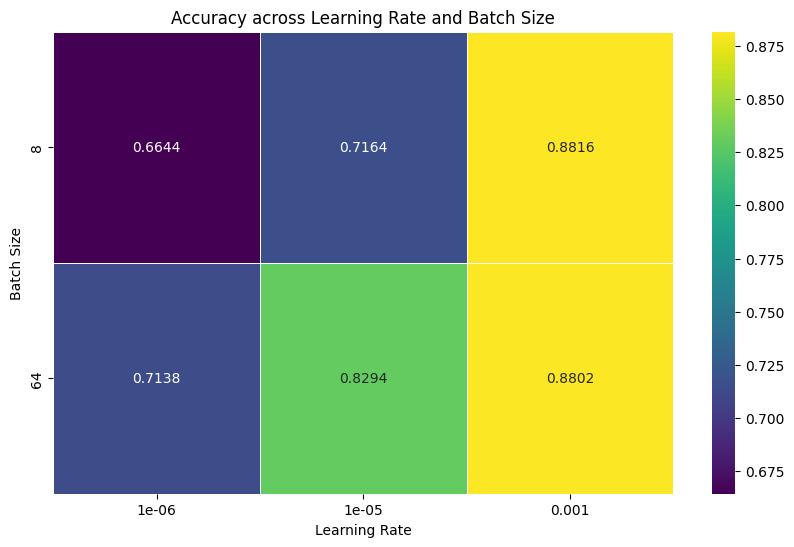

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Extract data from all_runs
learning_rates = []
batch_sizes = []
accuracies = []
steps = []

for l_rate, b_size, acc, s in all_runs:
    learning_rates.append(l_rate)
    batch_sizes.append(b_size)
    accuracies.append(acc)
    steps.append(s)

# Create a DataFrame
df = pd.DataFrame({
    'Learning Rate': learning_rates,
    'Batch Size': batch_sizes,
    'Accuracy': accuracies
})

# Pivot the DataFrame for heatmap
heatmap_data = df.pivot(index='Batch Size', columns='Learning Rate', values='Accuracy')

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap='viridis', fmt=".4f", linewidths=.5)
plt.title('Accuracy across Learning Rate and Batch Size')
plt.show()